In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
from scipy.optimize import curve_fit
import camb
from camb import model, initialpower

In [ ]:
a = np.loadtxt("a_distanceme.txt")
zd = np.loadtxt("z_distanceme.txt")
zm = np.loadtxt("z_matterme.txt")
k = np.loadtxt("k_hme.txt")
ells = np.loadtxt("ellsme.txt")
klin = np.loadtxt("k_h_lin.txt")
klin[-1]

0.15

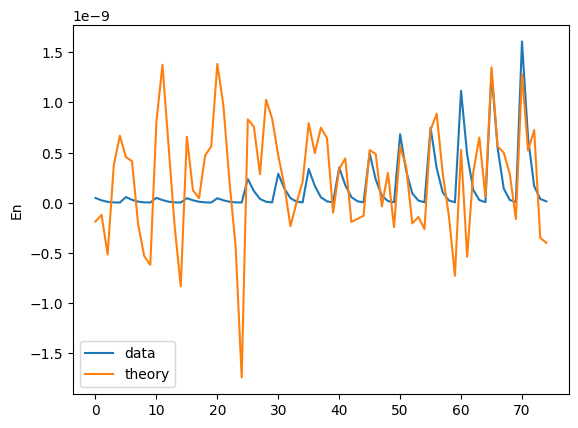

In [71]:
theory = np.loadtxt("data-theory(kids_nl_theta60).txt", skiprows=1)[:,0]
data = np.loadtxt("data-theory(kids_nl_theta60).txt", skiprows=1)[:,1]

plt.plot(data, label = "data")
plt.plot(theory, label = "theory")
plt.ylabel("En")
plt.legend();

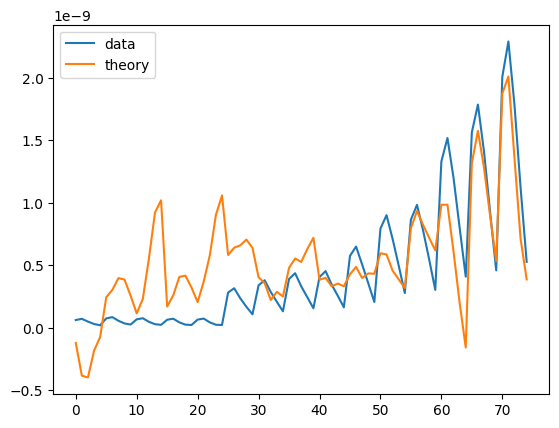

In [ ]:
theory = np.loadtxt("data-theory(kids_nl).txt", skiprows=1)[:,0]
data = np.loadtxt("data-theory(kids_nl).txt", skiprows=1)[:,1]

plt.plot(data, label = "data")
plt.plot(theory, label = "theory")
plt.legend();

/tmp/ipykernel_3732/157111858.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend();


np.float64(473.58840562451064)

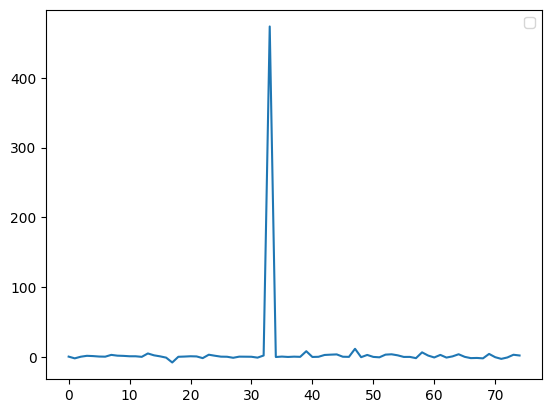

In [ ]:
x=0 #0:theory , 1:data , 2:diff , 3:diff_frac(/data), 4:diff_frac(/theory)
datatheory = np.loadtxt("data-theory(kids_nl_theta60).txt", skiprows=1)[:,x]
datatheorykidsnl = np.loadtxt("data-theory(kids_nl).txt", skiprows=1)[:,x]
cov = np.loadtxt("cov_theta60.txt")
covkidsnl = np.loadtxt("cov_kids_nl.txt")

diff= [(datatheory -datatheorykidsnl),(datatheory - datatheorykidsnl)/datatheory]

# plt.plot(datatheorykidsnl, label = "0.5")
# plt.plot(datatheory, label = "60.0")
plt.plot(diff[1])
plt.legend();
# plt.plot(diff015)
# print(np.where(np.abs(datatheory)>200))
# print(datatheory.shape)


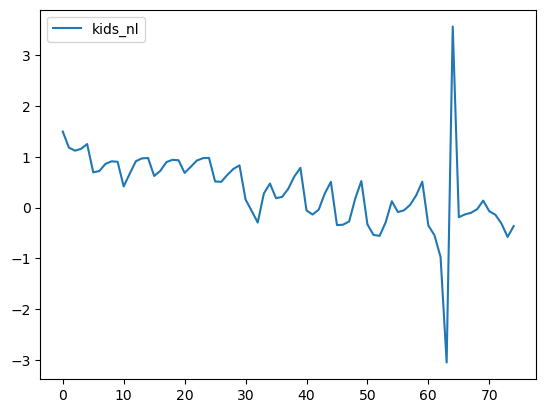

In [150]:
x=3 #0:theory , 1:data , 2:diff , 3:diff_frac
datatheoryme = np.loadtxt("data-theory(me_lin).txt", skiprows=1)[:,x]
datatheorykids = np.loadtxt("data-theory(kids_lin).txt", skiprows=1)[:,x]
datatheorykidsnl = np.loadtxt("data-theory(kids_nl).txt", skiprows=1)[:,x]
diff= (datatheoryme -datatheorykids)/datatheoryme
# plt.plot(datatheoryme, markersize = 4,label = "me")
# plt.plot(datatheorykids, label = "kids_lin")
plt.plot(datatheorykidsnl, label = "kids_nl")
plt.legend();
# plt.plot(diff)

x=3 #0:theory , 1:data , 2:diff , 3:diff_frac
datatheoryme015 = np.loadtxt("data-theory(me_lin015).txt", skiprows=1)[:,x]
datatheorykids015 = np.loadtxt("data-theory(kids_lin015).txt", skiprows=1)[:,x]
# datatheorykidsnl015 = np.loadtxt("data-theory(kids_nl015).txt", skiprows=1)[:,x]
diff015= (datatheoryme015 -datatheorykids015)/datatheoryme015
# plt.plot(datatheoryme015, markersize = 4,label = "me")
# plt.plot(datatheorykids, label = "kids_lin")
# plt.plot(datatheorykidsnl, label = "kids_nl")
# plt.legend();
# plt.plot(diff015)


/tmp/ipykernel_218685/463573426.py:3: RuntimeWarning: invalid value encountered in divide
  diff = [wme-wkids,(wme-wkids)/wme]


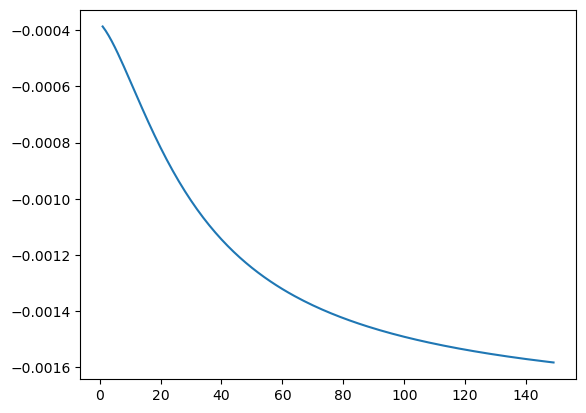

In [41]:
wme = np.loadtxt("w_kids.txt")
wkids = np.loadtxt("w_me.txt")
diff = [wme-wkids,(wme-wkids)/wme]

plt.plot(diff[1])
# plt.plot(wme)
# plt.plot(wkids)

In [126]:
kvals015 = np.loadtxt("kvals015.txt")
ells015 = np.loadtxt("ells015.txt")
ells = np.loadtxt("ells.txt")
# print(kvals015)
# print(ells015)
# print(ells)
print(kvals015.shape)
kvals015[-1]

(50, 445)


array([2000.1       ,  619.12350898,  366.24694342,  260.0367814 ,
        201.57951964,  164.58106708,  139.05798653,  120.3882824 ,
        106.1383203 ,   94.90475849,   85.82150574,   78.32507977,
         72.03306118,   66.6767754 ,   62.0619301 ,   58.04454063,
         54.51563737,   51.39123181,   48.60554599,   46.10633071,
         43.8515575 ,   41.807036  ,   39.94466811,   38.24114892,
         36.67698647,   35.23575254,   33.90350351,   32.66832774,
         31.51998843,   30.44963925,   29.44959602,   28.51315193,
         27.63442695,   26.80824422,   26.03002798,   25.29571883,
         24.60170285,   23.94475212,   23.32197458,   22.73077139,
         22.16880071,   21.63394673,   21.12429298,   20.63809946,
         20.17378275,   19.72989876,   19.3051278 ,   18.89826141,
         18.50819092,   18.13389731,   17.77444241,   17.42896093,
         17.09665363,   16.77678103,   16.46865803,   16.1716489 ,
         15.88516299,   15.60865078,   15.34160033,   15.08353

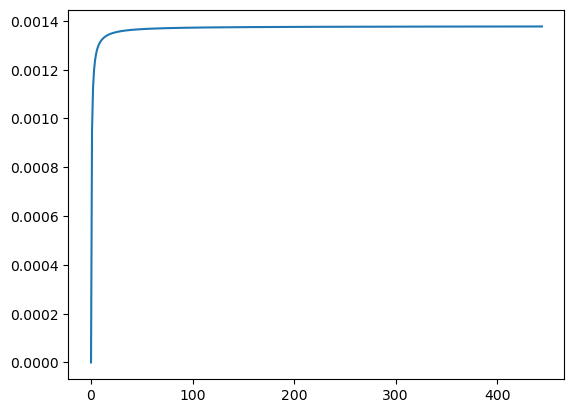

In [35]:
pkvalsme = np.loadtxt("PKVALS_me_lin.txt")
pkvalskids = np.loadtxt("PKVALS_kids_lin.txt")
chivalme = np.loadtxt("chival_me.txt")
chivalkids = np.loadtxt("chival_kids.txt")
k1k2me = np.loadtxt("k1k2_me.txt")
k1k2kids = np.loadtxt("k1k2_kids.txt")
diffpk = [pkvalsme - pkvalskids,(pkvalsme - pkvalskids)/pkvalsme]
diffk1k2 = [k1k2me - k1k2kids, (k1k2me - k1k2kids)/k1k2me]
diffchi = [chivalme - chivalkids,(chivalme - chivalkids)/chivalme]
# chivalme.shape
plt.plot(diffchi[1][-1]);
# plt.plot(chivalme[0])

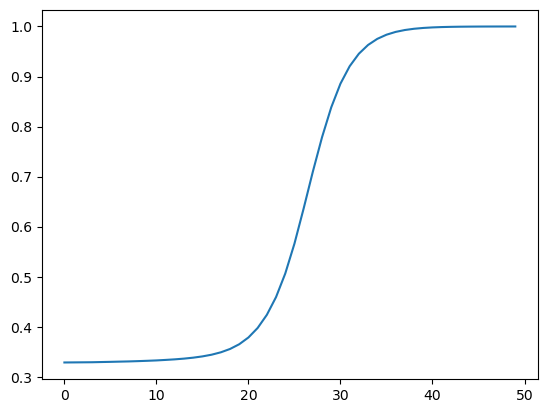

In [137]:
cellme = np.loadtxt("cell_me.txt")
cellkids = np.loadtxt("cell_kids.txt")
diff = [cellme-cellkids,(cellme-cellkids)/cellme]
# plt.plot(diff[1])

cellme015 = np.loadtxt("cell_me015.txt")
cellkids015 = np.loadtxt("cell_kids015.txt")
diff015 = [cellme015-cellkids015,(cellme015-cellkids015)/cellme015]
# plt.plot(cellme015)
# plt.plot(cellkids015)
# plt.plot(diff015[1])

difftot = [cellme015-cellkids,(cellme015-cellkids)/cellme015]
plt.plot(difftot[1]);

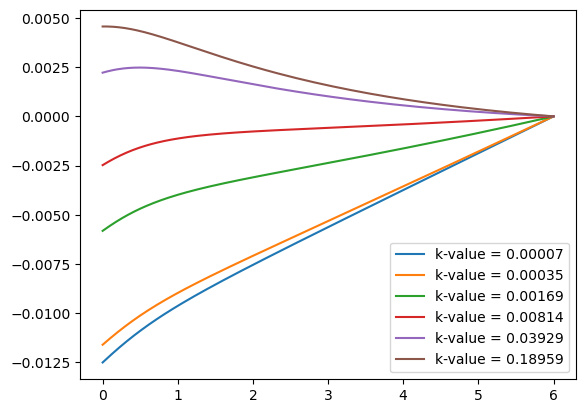

In [117]:
k20 = np.loadtxt("k_h20.txt")
pm_melin = np.loadtxt("pm_lin_me.txt")
pm_kidslin = np.loadtxt("pm_lin_kids.txt")
diff_pm = (pm_melin-pm_kidslin)/pm_melin
test = []
# kvalue = 0.2
# index = np.argmin(np.abs(k-kvalue))   
for i in range(0,diff_pm.shape[0]) :
    test.append(diff_pm[i])
test = np.array(test)

# Plotting the fractional error of power spectrum in ascending redshift
for i in range(0,test.shape[0],25) :
    plt.plot(zm,test[:,i], label = f"k-value = {k20[i]:.5f}")
# plt.plot(zm,test, label = f"k-value = {k[index]}")
plt.legend()

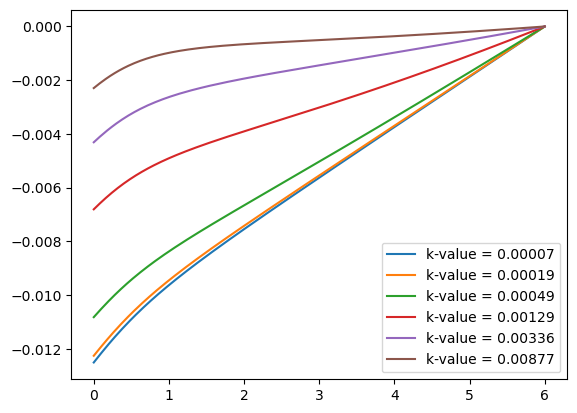

In [118]:
k015 = np.loadtxt("k_h015.txt")
pm_melin015 = np.loadtxt("pm_lin_me015.txt")
pm_kidslin015 = np.loadtxt("pm_lin_kids015.txt")
diff_pm015 = (pm_melin015-pm_kidslin015)/pm_melin015
test = []
# kvalue = 0.2
# index = np.argmin(np.abs(k-kvalue))   
for i in range(0,diff_pm015.shape[0]) :
    test.append(diff_pm015[i])
test = np.array(test)

# Plotting the fractional error of power spectrum in ascending redshift
for i in range(0,test.shape[0],25) :
    plt.plot(zm,test[:,i], label = f"k-value = {k015[i]:.5f}")
# plt.plot(zm,test, label = f"k-value = {k[index]}")
plt.legend()

In [202]:
x=np.diff(pm_kidslin20)
np.where(x==0)[0]
k20[128]

0.22900557000799582

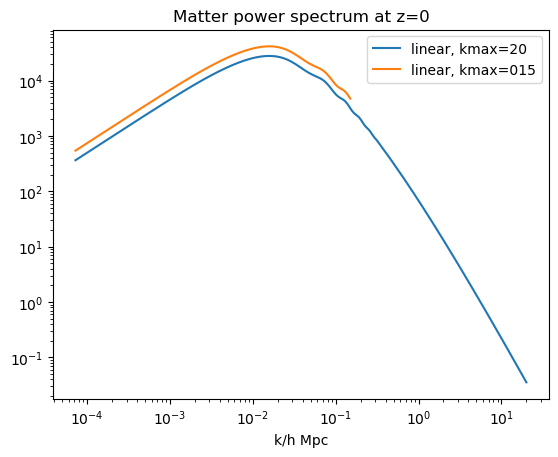

In [7]:
k1 = np.loadtxt("k_h1.0.txt")
pm_kidslin1 = np.loadtxt("pm_lin_kids1.0.txt")[0]

k20 = np.loadtxt("k_h20_noext.txt")
# pm_melin = np.loadtxt("pm_lin_me.txt")[0]
pm_kidslin20 = np.loadtxt("pm_lin_kids20_noext.txt")[0]
# pm_kidsnl = np.loadtxt("pm_nl_kids.txt")[0]

k20ext = np.loadtxt("k_h20_ext.txt")
pm_kidslin20ext = np.loadtxt("pm_lin_kids20_ext.txt")[0]

k015 = np.loadtxt("k_h015.txt")
pm_melin015 = np.loadtxt("pm_lin_me015.txt")[0]
pm_kidslin015 = np.loadtxt("pm_lin_kids015.txt")[0]
pm_kidsnl015 = np.loadtxt("pm_nl_kids015.txt")[0]

plt.loglog(k20,pm_kidslin20, label="linear, kmax=20")
# plt.loglog(k20ext,pm_kidslin20ext, label="linear20ext")
plt.loglog(k015,pm_kidslin015, label="linear, kmax=015")
# plt.loglog(k1,pm_kidslin1, label="linear1")
plt.title("Matter power spectrum at z=0")
plt.xlabel("k/h Mpc")
plt.legend()


In [3]:
print(k1[0]==k20[0])
print(pm_kidslin1[0]-pm_kidslin20[0])

True
0.2276728304833


In [170]:
z015 = np.loadtxt("z_matter015.txt")
z20 = np.loadtxt("z_matter20.txt")
z015 == z20

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

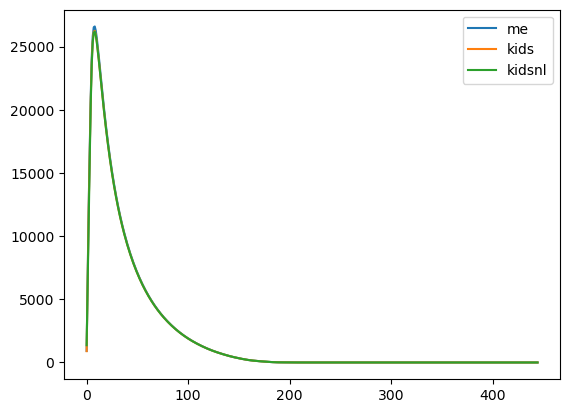

In [196]:
ell = 0
plt.plot(integrandme[ell], label = "me")
plt.plot(integrandkids[ell], label = "kids")
plt.plot(integrandkidsnl[ell], label = "kidsnl")
plt.legend();

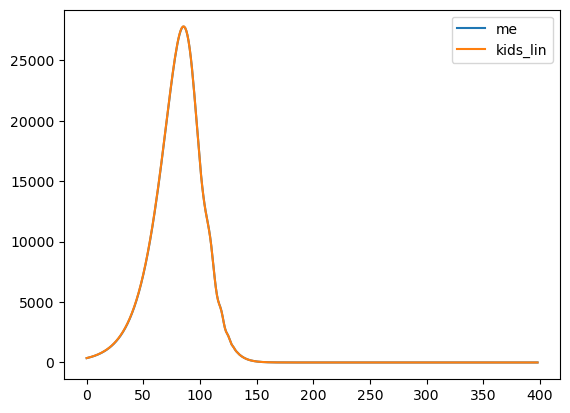

In [32]:
a = np.loadtxt("a_distanceme.txt")
zd = np.loadtxt("z_distanceme.txt")
zm = np.loadtxt("z_matterme.txt")
k = np.loadtxt("k_hme.txt")
ells = np.loadtxt("ellsme.txt")
k1k2me = np.loadtxt("k1k2_me.txt")
k1k2kids = np.loadtxt("k1k2_kids.txt")
chime = np.loadtxt("chi_me.txt")
chikids = np.loadtxt("chi_kids.txt")
chikernelme = np.loadtxt("chivalskernel_me.txt")
chikernelkids = np.loadtxt("chivalskernel_kids.txt")
wofchime = np.loadtxt("w_of_chi_vals_me.txt")
wofchikids = np.loadtxt("w_of_chi_vals_kids.txt")
iame = np.loadtxt("ia_me.txt")
iakids = np.loadtxt("ia_kids.txt")
wofchipreme = np.loadtxt("wofchipre_me.txt")
wofchiprekids = np.loadtxt("wofchipre_kids.txt")
avalskernelme = np.loadtxt("avals_me.txt")
avalskernelkids = np.loadtxt("avals_kids.txt")
integrandme = np.loadtxt("integrands_me.txt")
integrandkids = np.loadtxt("integrands_kids.txt")
integrandkidsnl = np.loadtxt("integrands_kidsnl.txt")
cellme = np.loadtxt("cell_me.txt")
cellkids = np.loadtxt("cell_kids.txt")
cellkidsnl = np.loadtxt("cell_kidsnl.txt")
pm_melin = np.loadtxt("pm_lin_me.txt")[0]
pm_kidslin = np.loadtxt("pm_lin_kids.txt")[0]
plt.plot(pm_melin, markersize = 2, label = "me")
plt.plot(pm_kidslin, label = "kids_lin")
# plt.plot(cellkidsnl, label = "kids_nl")


plt.legend();

Note: redshifts have been re-sorted (earliest first)


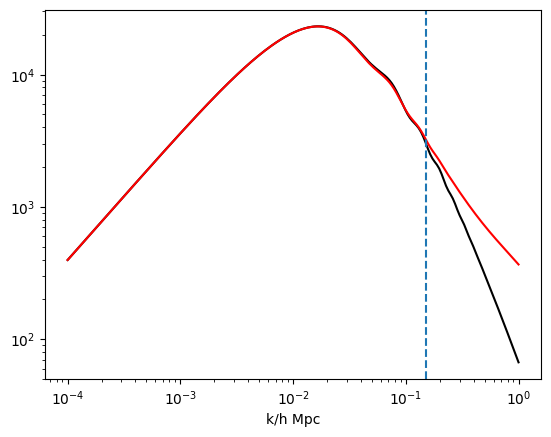

In [71]:
# Now get matter power spectra and sigma8 at redshift 0 and 0.8
# parameters can all be passed as a dict as above, or you can call 
# separate functions to set up the parameter object
pars1 =  camb.set_params(H0=67.5, ombh2=0.022, omch2=0.122, ns=0.965)
#Note non-linear corrections couples to smaller scales than you want
pars1.set_matter_power(redshifts=[0., 6.0], kmax=2.0)

#Linear spectra
pars1.NonLinear = model.NonLinear_none
results = camb.get_results(pars1)
kh, z, pk = results.get_matter_power_spectrum(minkh=1e-4, maxkh=1, npoints = 200)
s8 = np.array(results.get_sigma8())

#Non-Linear spectra (Halofit)
pars1.NonLinear = model.NonLinear_both
results.calc_power_spectra(pars1)
kh_nonlin, z_nonlin, pk_nonlin = results.get_matter_power_spectrum(minkh=1e-4, maxkh=1, npoints = 200)

plt.loglog(kh, pk[0,:], color='k', label="linear")
plt.loglog(kh_nonlin, pk_nonlin[0,:], color='r', label="non-linear")
plt.axvline(x=0.15, linestyle="--")
plt.xlabel('k/h Mpc');

Note: redshifts have been re-sorted (earliest first)


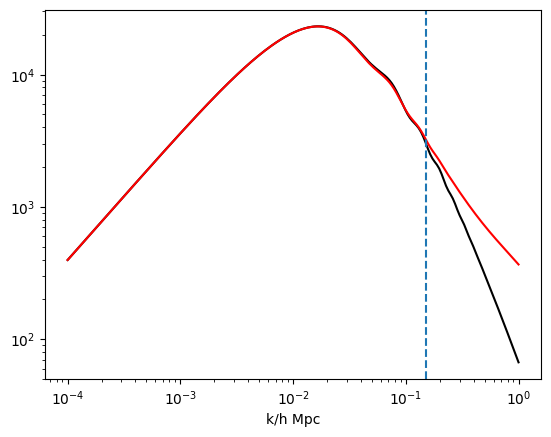

In [73]:
# Now get matter power spectra and sigma8 at redshift 0 and 0.8
# parameters can all be passed as a dict as above, or you can call 
# separate functions to set up the parameter object
pars1 =  camb.set_params(H0=67.5, ombh2=0.022, omch2=0.122, ns=0.965)
#Note non-linear corrections couples to smaller scales than you want
pars1.set_matter_power(redshifts=[0., 6.0], kmax=2.0)

#Linear spectra
pars1.NonLinear = model.NonLinear_none
results = camb.get_results(pars1)
kh, z, pk = results.get_matter_power_spectrum(minkh=1e-4, maxkh=1, npoints = 200)
s8 = np.array(results.get_sigma8())

#Non-Linear spectra (Halofit)
pars1.NonLinear = model.NonLinear_both
results.calc_power_spectra(pars1)
kh_nonlin, z_nonlin, pk_nonlin = results.get_matter_power_spectrum(minkh=1e-4, maxkh=1, npoints = 200)

plt.loglog(kh, pk[0,:], color='k', label="linear")
plt.loglog(kh_nonlin, pk_nonlin[0,:], color='r', label="non-linear")
plt.axvline(x=0.15, linestyle="--")
plt.xlabel('k/h Mpc');

In [53]:
# Now get matter power spectra and sigma8 at redshift 0 and 0.8
# parameters can all be passed as a dict as above, or you can call 
# separate functions to set up the parameter object
pars1 =  camb.set_params(H0=67.5, ombh2=0.022, omch2=0.122, ns=0.965)
#Note non-linear corrections couples to smaller scales than you want
pars1.set_matter_power(redshifts=[0., 6.0], kmax=20.0)

#Linear spectra
pars1.NonLinear = model.NonLinear_none
results1 = camb.get_results(pars1)
# kh, z, pk = results.get_matter_power_spectrum(minkh=1e-4, maxkh=20.0, npoints = 200)
pk1, z1, kh1 = results.get_matter_power_interpolator(nonlinear=False, return_z_k=True,extrap_kmax=20.0)
k1 = np.logspace(np.log10(kh1[0]), np.log10(20.0), 200)
p_k1 = pk1.P(z1,k1,grid=True)
s8_1 = np.array(results1.get_sigma8())

#Non-Linear spectra (Halofit)
pars1.NonLinear = model.NonLinear_both
results.calc_power_spectra(pars1)
kh_nonlin, z_nonlin, pk_nonlin = results.get_matter_power_spectrum(minkh=1e-4, maxkh=1, npoints = 200)

# for i, (redshift, line) in enumerate(zip(z,['-','--'])):
#     plt.loglog(kh, pk[i,:], color='k', ls = line)
#     plt.loglog(kh_nonlin, pk_nonlin[i,:], color='r', ls = line)

pars2 =  camb.set_params(H0=67.5, ombh2=0.022, omch2=0.122, ns=0.965)
#Note non-linear corrections couples to smaller scales than you want
pars2.set_matter_power(redshifts=[0., 6.0], kmax=0.15)

#Linear spectra
pars2.NonLinear = model.NonLinear_none
results2 = camb.get_results(pars2)
# kh2, z2, pk2 = results.get_matter_power_spectrum(minkh=1e-4, maxkh=0.15, npoints = 200)
pk2, z2, kh2= results.get_matter_power_interpolator(nonlinear=False, return_z_k=True,extrap_kmax=0.15)
k2 = np.logspace(np.log10(kh2[0]), np.log10(0.15), 200)
p_k2 = pk2.P(z2,k2,grid=True)
s8_2 = np.array(results.get_sigma8())

plt.loglog(k1,p_k1[0], label = "linear20", marker = ".", markersize = 3)
plt.loglog(kh_nonlin,pk_nonlin[0], label = "non-linear", marker = ".", markersize = 3)
# plt.loglog(k2,p_k2[0], label = "linear015",marker = "*", markersize = 2)
# plt.loglog(k20,pm_kidslin20, label="linear20_pipeline")
# plt.loglog(k015,pm_kidslin015, label="linear015_pipeline")
plt.xlabel('k/h Mpc');
plt.legend();
# plt.title('Matter power at z=%s and z= %s'%tuple(z));

Note: redshifts have been re-sorted (earliest first)


AssertionError: 

In [239]:
k1[0]==k2[0]
p_k1[1]==p_k2[1]

array([ True, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,

In [164]:
ell=132
theta=180/ell * 60
print(theta)

81.81818181818181


In [59]:
theta = 60
ell = 180/(theta/60)
print(ell)

180.0


In [155]:
pars =  camb.set_params(H0=67.5, ombh2=0.022, omch2=0.120, ns=0.965)
results = camb.get_results(pars)

z=0.5
dc = results.comoving_radial_distance(z)
da = 1/(1+z) * dc

k=0.1
ell = k*da
# print(da)
print(ell)

# z = np.linspace(0,6.0,100)
# dc = results.comoving_radial_distance(z)
# da = 1/(1+z)*dc
# plt.plot(z,dc)

129.97964590325822


In [28]:
tmin=40.00
tmax=250.00
ntheta=10000
theta=np.logspace(np.log10(tmin),np.log10(tmax),ntheta)

theta[0]

np.float64(40.000000000000014)

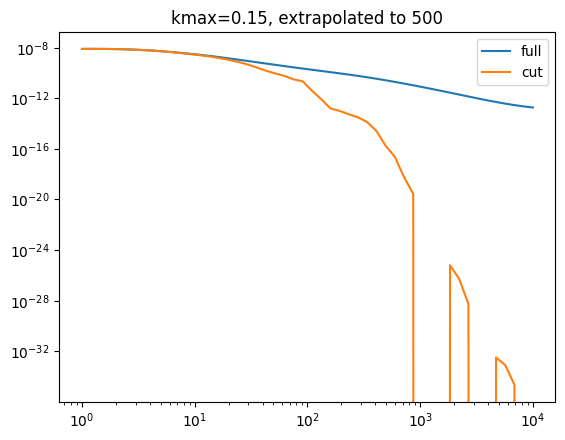

In [ ]:
cell_full = np.loadtxt("cell_kids_nl_k500_bin1_1")
cell_cut = np.loadtxt("cell_kids_nl_k015_bin1_1")
ells = np.loadtxt("ells.txt")

plt.loglog(ells, cell_full, label="full")
plt.loglog(ells, cell_cut, label="cut")
plt.title("kmax=0.15, extrapolated to 500")
plt.legend()

29.4705170255181


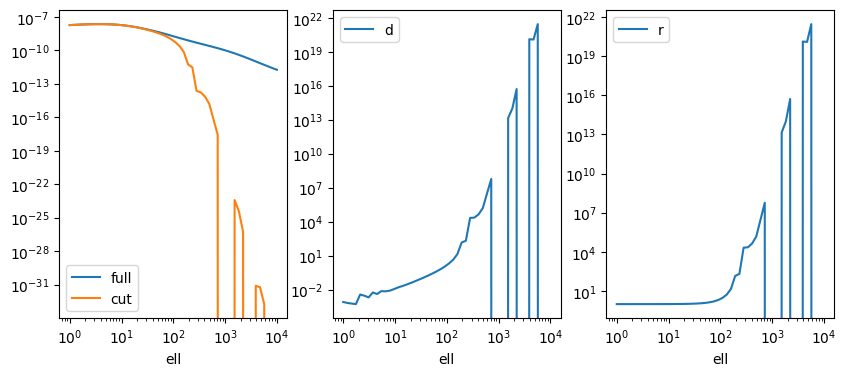

In [162]:
bin1 = 3
bin2 = 3
cell_full = np.loadtxt(f"cell_kids_nl_k500_bin{bin1}_{bin2}")
cell_cut = np.loadtxt(f"cell_kids_nl_k015_bin{bin1}_{bin2}")
ells = np.loadtxt("ells.txt")

diff = [cell_full-cell_cut,(cell_full-cell_cut)/cell_cut]
ratio = cell_full/cell_cut
print(ells[np.min(np.where((diff[1]>0.1) == True))-1])

plt.figure(figsize=(10,4));
plt.subplot(1,3,1);
plt.loglog(ells, cell_full, label="full")
plt.loglog(ells, cell_cut, label="cut")
plt.xlabel("ell")
# plt.title("kmax=500, cut to 0.15")
plt.legend();
plt.subplot(1,3,2);
plt.loglog(ells,diff[1])
plt.xlabel("ell")
# plt.title("kmax=500, cut to 0.15")
plt.legend("difference");
plt.subplot(1,3,3);
plt.loglog(ells,ratio)
plt.xlabel("ell")
# plt.title("kmax=500, cut to 0.15")
plt.legend("ratio");

In [34]:
np.where((diff[1]>0.05) == True)

(array([12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28,
        29, 30, 31, 32, 33, 34, 35, 36, 40, 41, 42, 45, 46, 47]),)

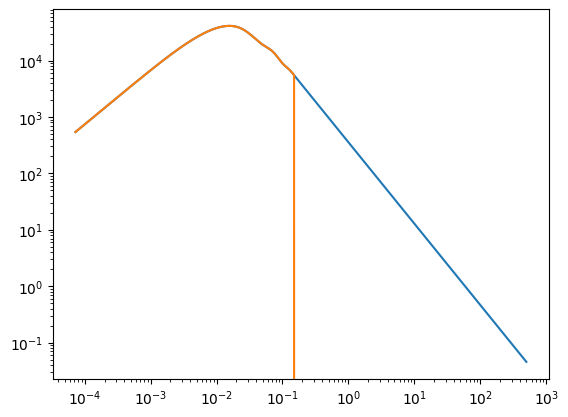

In [10]:
test_cut_before = np.loadtxt("test_cut_before.txt")[0]
test_cut_after = np.loadtxt("test_cut_after.txt")[0]
k_test_cut = np.loadtxt("k_test_cut.txt")
plt.loglog(k_test_cut,test_cut_before);
plt.loglog(k_test_cut,test_cut_after);

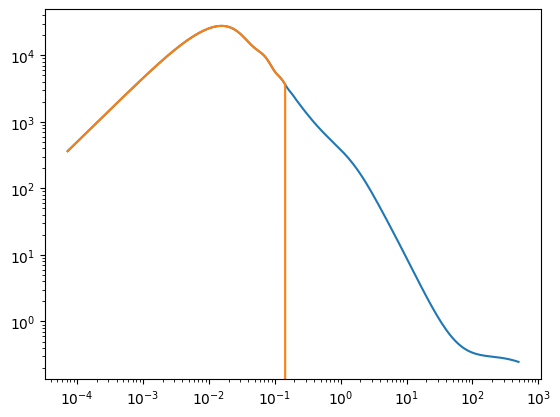

In [12]:
test_cut_before = np.loadtxt("500test_cut_before.txt")[0]
test_cut_after = np.loadtxt("500test_cut_after.txt")[0]
k_test_cut = np.loadtxt("500k_test_cut.txt")
plt.loglog(k_test_cut,test_cut_before);
plt.loglog(k_test_cut,test_cut_after);

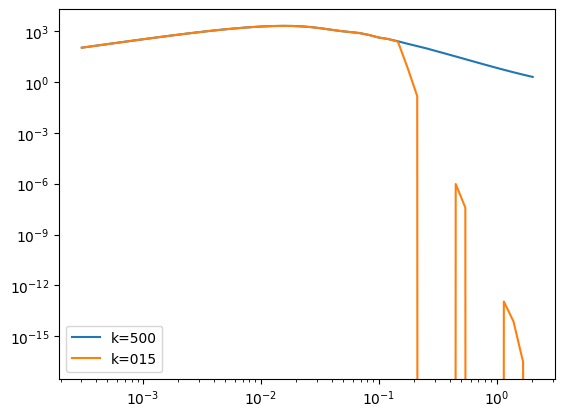

In [66]:
pk_500 = np.loadtxt("PK_VALS_k500.txt")[:,]
k_500 = np.loadtxt("K_VALS_k500.txt")[:,-1]
pk_015 = np.loadtxt("PK_VALS_k015.txt")[:,-1]
k_015 = np.loadtxt("K_VALS_k015.txt")[:,-1]

plt.loglog(k_500,pk_500,label="k=500")
plt.loglog(k_015,pk_015,label="k=015")
plt.legend();

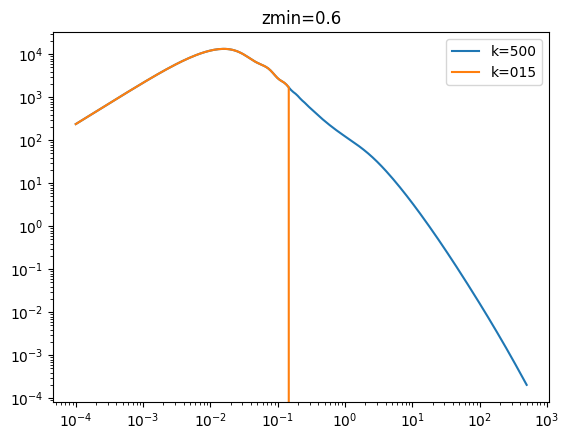

In [147]:
pk_500 = np.loadtxt("pk_mycamb_nl_500_zmin06.txt")[0]
k_500 = np.loadtxt("k_mycamb_500_zmin06.txt")
pk_015 = np.loadtxt("pk_mycamb_nl_015_zmin06.txt")[0]

plt.loglog(k_500,pk_500,label="k=500")
plt.loglog(k_500,pk_015,label="k=015")
plt.title("zmin=0.6")
plt.legend();

132.57113655901082


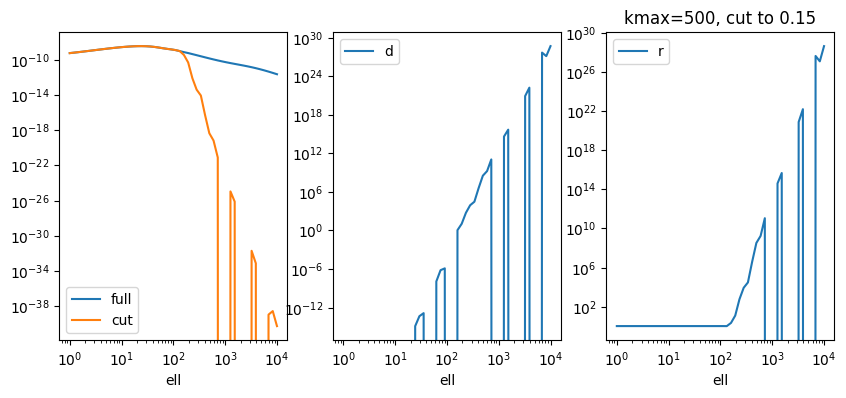

In [166]:
bin1 = 5
bin2 = 5
cell_full = np.loadtxt(f"cell_mycamb_nl_k500_zmin05_bin{bin1}_{bin2}")
cell_cut = np.loadtxt(f"cell_mycamb_nl_k01_zmin05_bin{bin1}_{bin2}")
ells = np.loadtxt("ells.txt")

diff = [cell_full-cell_cut,(cell_full-cell_cut)/cell_cut]
ratio = cell_full/cell_cut
print(ells[np.min(np.where((diff[1]>0.05) == True))-1]) # the value of ell at which the error is larger than 10%

plt.figure(figsize=(10,4));
plt.subplot(1,3,1);
plt.loglog(ells, cell_full, label="full")
plt.loglog(ells, cell_cut, label="cut")
plt.xlabel("ell")
# plt.title("kmax=500, cut to 0.15")
plt.legend();
plt.subplot(1,3,2);
plt.loglog(ells,diff[1])
plt.xlabel("ell")
# plt.title("kmax=500, cut to 0.15")
plt.legend("difference");
plt.subplot(1,3,3);
plt.loglog(ells,ratio)
plt.xlabel("ell")
plt.title("kmax=500, cut to 0.15")
plt.legend("ratio");

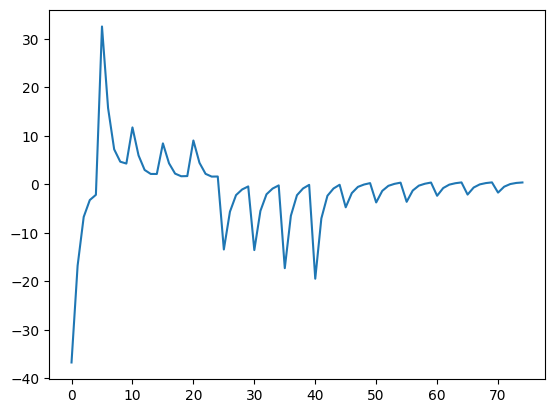

In [161]:
cosebis015 = np.loadtxt("COSEBIs_k015")
cosebis500 = np.loadtxt("COSEBIs_k500")
diff = [cosebis015 - cosebis500,(cosebis015 - cosebis500)/cosebis015]
plt.plot(diff[1])

In [ ]:
omega_m_marie = 0.2589 +- 0.0123
0.2594 +- 0.0074 #without expansion function (model-independent)